# Week 4: Modeling and Evaluation

This notebook trains and evaluates fraud detection models on the engineered dataset. Because fraudulent transactions are rare, the evaluation prioritizes PR-AUC, ROC-AUC, precision, recall, F1-score, and confusion-matrix behavior rather than accuracy alone.

## 1. Import Libraries

The notebook imports the core data-science stack, baseline classifiers, tree-based models, and evaluation metrics used throughout the modeling stage. `classification_report`, ROC utilities, and Precision-Recall utilities are included because the final report needs both class-level metrics and test-set curves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

## 2. Load Engineered Train/Test Data

The modeling step uses the feature-engineered datasets from Week 3. `Class` is separated as the target label, while all remaining columns are used as model features. The printed class ratios help confirm that the fraud class is extremely rare.

In [2]:
train_df = pd.read_csv("../data/processed/train_fe.csv")
test_df = pd.read_csv("../data/processed/test_fe.csv")

X_train_full = train_df.drop(columns=["Class"])
y_train_full = train_df["Class"]

X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]

print(X_train_full.shape, X_test.shape)
print(y_train_full.mean(), y_test.mean())

(227845, 47) (56962, 47)
0.001830191577607584 0.001316667251852112


## 3. Create a Validation Split

The original training data is split into a training subset and a validation subset. Validation is used for model comparison and threshold tuning so the held-out test set remains untouched until the final evaluation.

In [3]:
split_val = int(len(X_train_full) * 0.8)

X_train = X_train_full.iloc[:split_val].copy()
y_train = y_train_full.iloc[:split_val].copy()

X_val = X_train_full.iloc[split_val:].copy()
y_val = y_train_full.iloc[split_val:].copy()

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (182276, 47) (182276,)
Val: (45569, 47) (45569,)
Test: (56962, 47) (56962,)


## 4. Define a Reusable Evaluation Function

This helper trains a model, converts predicted probabilities into class predictions at a selected threshold, and returns the main evaluation metrics. The same function is reused for all baseline models to keep the comparison consistent.

In [4]:
def evaluate_model(model, X_train, y_train, X_eval, y_eval, threshold=0.5, model_name="Model"):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, y_prob),
        "PR_AUC": average_precision_score(y_eval, y_prob)
    }

    return model, y_prob, y_pred, metrics

## 5. Define Baseline and Candidate Models

The model set includes a Dummy Classifier, Logistic Regression, Random Forest, XGBoost, and LightGBM. The Dummy Classifier provides a floor for comparison, while Random Forest and XGBoost are expected to handle nonlinear feature interactions better.

In [5]:
dummy = DummyClassifier(strategy="most_frequent")

In [6]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [7]:
rf = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

## 6. Configure XGBoost for Class Imbalance

Fraud is the minority class, so XGBoost receives `scale_pos_weight` based on the training subset. This makes positive fraud examples more influential during training and helps avoid a model that simply predicts the majority class.

In [8]:
neg_count_train = (y_train == 0).sum()
pos_count_train = (y_train == 1).sum()
scale_pos_weight_train = neg_count_train / pos_count_train

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_train,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [9]:
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

## 7. Train and Compare Models on the Validation Set

Each model is trained on the training subset and evaluated on the validation subset at the default threshold of 0.5. The table is sorted by PR-AUC because Precision-Recall performance is more informative than accuracy for heavily imbalanced fraud data.

In [10]:
results = []
trained_models = {}
predictions_val = {}

models = [
    (dummy, "Dummy"),
    (log_reg, "Logistic Regression"),
    (rf, "Random Forest"),
    (xgb, "XGBoost"),
    (lgbm, "LightGBM")
]

for model, name in models:
    fitted_model, y_prob, y_pred, metrics = evaluate_model(
        model, X_train, y_train, X_val, y_val, threshold=0.5, model_name=name
    )
    results.append(metrics)
    trained_models[name] = fitted_model
    predictions_val[name] = {"y_prob": y_prob, "y_pred": y_pred}

results_df = pd.DataFrame(results).sort_values(by="PR_AUC", ascending=False)
results_df

c:\Users\ADMIN\anaconda3\envs\fraud-xai\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,XGBoost,0.999561,0.847826,0.750000,0.795918,0.979172,0.784497
2,Random Forest,0.999407,0.931034,0.519231,0.666667,0.928577,0.752069
1,Logistic Regression,0.983168,0.053683,0.826923,0.100821,0.963050,0.707001
0,Dummy,0.998859,0.000000,0.000000,0.000000,0.500000,0.001141
4,LightGBM,0.997586,0.000000,0.000000,0.000000,0.498847,0.001141


## 8. Validation ROC Curves

ROC curves summarize how well each model separates fraud from non-fraud across possible thresholds. They are useful for checking ranking quality, but they should not be the only evidence because ROC-AUC can look overly optimistic on imbalanced datasets.

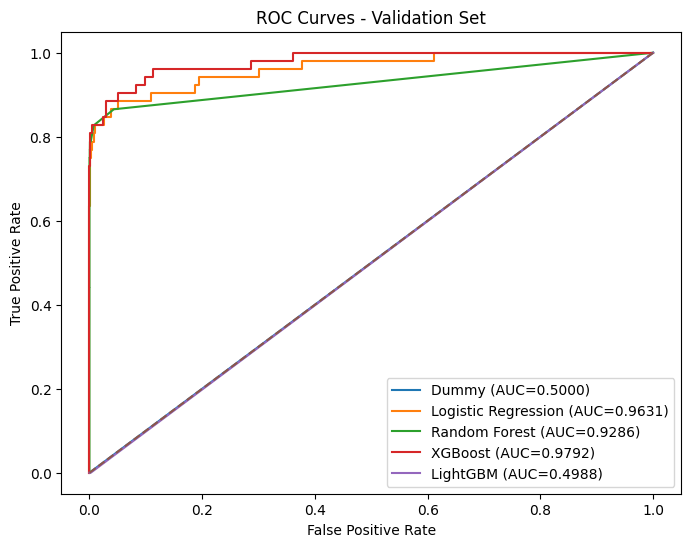

In [11]:
plt.figure(figsize=(8,6))

for name in predictions_val:
    y_prob = predictions_val[name]["y_prob"]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Validation Set")
plt.legend()
plt.show()

## 9. Validation Precision-Recall Curves

Precision-Recall curves are especially important for this project because fraud is rare. PR-AUC shows whether a model can capture fraudulent transactions while keeping false alerts under control.

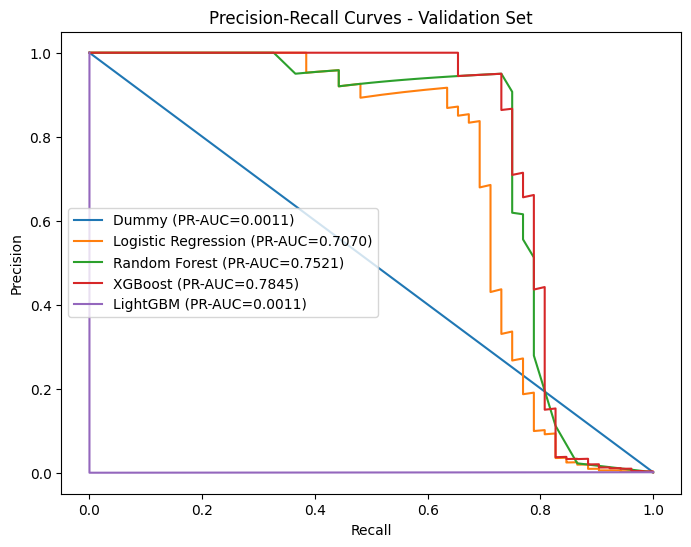

In [12]:
plt.figure(figsize=(8,6))

for name in predictions_val:
    y_prob = predictions_val[name]["y_prob"]
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Validation Set")
plt.legend()
plt.show()

## 10. Threshold-Tuning Function

Fraud detection usually should not rely on the default threshold of 0.5. This function evaluates a grid of thresholds and records precision, recall, F1-score, true/false positives, true/false negatives, fraud capture rate, and false alert rate.

In [13]:
def evaluate_thresholds(y_true, y_prob, thresholds):
    rows = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "fraud_capture_rate": tp / (tp + fn + 1e-9),
            "false_alert_rate": fp / (fp + tn + 1e-9)
        })

    return pd.DataFrame(rows)

## 11. Select Models for Threshold Tuning

Random Forest and XGBoost are kept as the main candidates because they are the strongest validation performers. LightGBM is not selected as the final model under the current configuration because its fraud-detection performance is weak.

In [14]:
candidate_models = ["Random Forest", "XGBoost"]

candidate_summary = (
    results_df[results_df["Model"].isin(candidate_models)]
    .set_index("Model")
    .loc[candidate_models, ["PR_AUC", "F1", "Recall", "Precision", "ROC_AUC"]]
)

candidate_summary

,PR_AUC,F1,Recall,Precision,ROC_AUC
Model,,,,,
Random Forest,0.752069,0.666667,0.519231,0.931034,0.928577
XGBoost,0.784497,0.795918,0.750000,0.847826,0.979172


## 12. Tune Random Forest and XGBoost Thresholds

The next cells evaluate candidate thresholds from 0.01 to 0.95. The best rows are sorted by F1-score and recall so the final selection balances fraud capture against false alarms.

In [15]:
thresholds = np.arange(0.01, 0.96, 0.01)

rf_threshold_df = evaluate_thresholds(
    y_true=y_val,
    y_prob=predictions_val["Random Forest"]["y_prob"],
    thresholds=thresholds
)

rf_threshold_df.sort_values(by=["f1", "recall"], ascending=False).head(10)

,threshold,precision,recall,f1,tn,fp,fn,tp,fraud_capture_rate,false_alert_rate
15,0.16,0.950000,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
16,0.17,0.950000,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
17,0.18,0.950000,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
18,0.19,0.950000,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
19,0.20,0.950000,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
20,0.21,0.950000,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
10,0.11,0.906977,0.750000,0.821053,45513,4,13,39,0.750000,0.000088
11,0.12,0.906977,0.750000,0.821053,45513,4,13,39,0.750000,0.000088
12,0.13,0.906977,0.750000,0.821053,45513,4,13,39,0.750000,0.000088
13,0.14,0.906977,0.750000,0.821053,45513,4,13,39,0.750000,0.000088


In [16]:
xgb_threshold_df = evaluate_thresholds(
    y_true=y_val,
    y_prob=predictions_val["XGBoost"]["y_prob"],
    thresholds=thresholds
)

xgb_threshold_df.sort_values(by=["f1", "recall"], ascending=False).head(10)

,threshold,precision,recall,f1,tn,fp,fn,tp,fraud_capture_rate,false_alert_rate
72,0.73,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
73,0.74,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
74,0.75,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
75,0.76,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
76,0.77,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
77,0.78,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
78,0.79,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
79,0.80,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
80,0.81,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044
81,0.82,0.95,0.730769,0.826087,45515,2,14,38,0.730769,0.000044


## 13. Choose the Final Model and Threshold

The threshold summary compares the best tuned threshold for Random Forest and XGBoost. XGBoost is selected when it has the strongest F1-score or materially better recall while keeping F1 close to Random Forest.

In [17]:
threshold_candidates = {
    "Random Forest": rf_threshold_df,
    "XGBoost": xgb_threshold_df
}

threshold_summary = pd.DataFrame([
    {"Model": name, **df.loc[df["f1"].idxmax()].to_dict()}
    for name, df in threshold_candidates.items()
])

threshold_summary = threshold_summary[
    [
        "Model",
        "threshold",
        "precision",
        "recall",
        "f1",
        "fraud_capture_rate",
        "false_alert_rate",
        "tn",
        "fp",
        "fn",
        "tp"
    ]
].sort_values(by=["f1", "recall"], ascending=False)

threshold_summary

,Model,threshold,precision,recall,f1,fraud_capture_rate,false_alert_rate,tn,fp,fn,tp
0,Random Forest,0.16,0.95,0.730769,0.826087,0.730769,0.000044,45515.0,2.0,14.0,38.0
1,XGBoost,0.73,0.95,0.730769,0.826087,0.730769,0.000044,45515.0,2.0,14.0,38.0


In [18]:
threshold_lookup = threshold_summary.set_index("Model")
rf_best = threshold_lookup.loc["Random Forest"]
xgb_best = threshold_lookup.loc["XGBoost"]

# Prefer XGBoost when it has the best F1, or when recall improves meaningfully
# while keeping F1 close to Random Forest. Otherwise, keep Random Forest.
if (xgb_best["f1"] >= rf_best["f1"]) or (
    (xgb_best["recall"] > rf_best["recall"]) and (xgb_best["f1"] >= 0.95 * rf_best["f1"])
):
    best_model_name = "XGBoost"
    threshold_df = xgb_threshold_df
else:
    best_model_name = "Random Forest"
    threshold_df = rf_threshold_df

best_validation_row = threshold_lookup.loc[best_model_name]
best_threshold = float(best_validation_row["threshold"])

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)
print("Validation F1:", best_validation_row["f1"])
print("Validation recall:", best_validation_row["recall"])
print("Validation precision:", best_validation_row["precision"])

Best model: XGBoost
Best threshold: 0.73
Validation F1: 0.8260869565217391
Validation recall: 0.7307692307692307
Validation precision: 0.95


## 14. Visualize the Threshold Trade-Off

These plots show how precision, recall, and F1-score change as the decision threshold changes. This makes the model-selection decision easier to justify in the report.

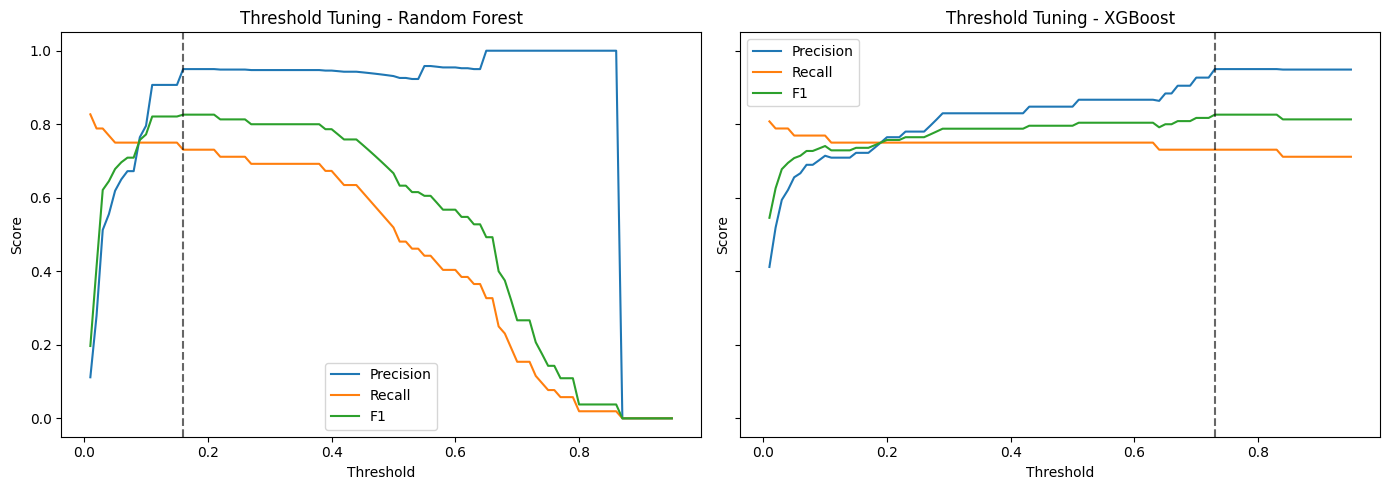

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, threshold_candidates.items()):
    best_line_threshold = (
        best_threshold
        if name == best_model_name
        else df.loc[df["f1"].idxmax(), "threshold"]
    )

    ax.plot(df["threshold"], df["precision"], label="Precision")
    ax.plot(df["threshold"], df["recall"], label="Recall")
    ax.plot(df["threshold"], df["f1"], label="F1")
    ax.axvline(
        best_line_threshold,
        linestyle="--",
        color="black",
        alpha=0.6,
    )
    ax.set_title(f"Threshold Tuning - {name}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend()

plt.tight_layout()
plt.show()


## 15. Retrain the Final Model on the Full Training Data

After choosing the final model and threshold using validation data, the selected model is retrained on the full training set. The held-out test set is still used only for final evaluation.

In [20]:
if best_model_name == "XGBoost":
    neg_count_full = (y_train_full == 0).sum()
    pos_count_full = (y_train_full == 1).sum()
    scale_pos_weight_full = neg_count_full / pos_count_full

    final_model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_full,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
else:
    raise ValueError(f"Unsupported final model: {best_model_name}")

final_model.fit(X_train_full, y_train_full)

y_test_prob = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

## 16. Final Test Metrics

The final model is evaluated on the held-out test set. Accuracy is shown for completeness, but precision, recall, F1-score, ROC-AUC, and PR-AUC are the primary metrics for this fraud detection task.

In [21]:
final_metrics = {
    "Model": best_model_name,
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob),
    "PR_AUC": average_precision_score(y_test, y_test_prob)
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.73,0.999544,0.888889,0.746667,0.811594,0.981518,0.789233


## 17. Test ROC and Precision-Recall Curves

These curves provide the required report figures for the final model on the test set. The images are also saved into `reports/` so they can be inserted into the written report without rerunning the notebook.

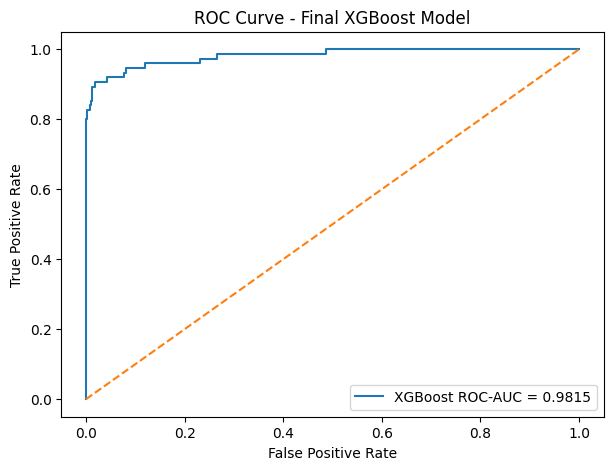

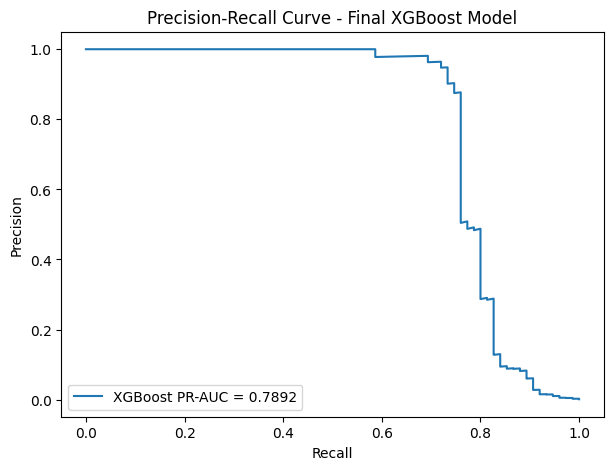

In [22]:
reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)

final_fpr, final_tpr, _ = roc_curve(y_test, y_test_prob)
final_roc_auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    final_fpr,
    final_tpr,
    label=f"{best_model_name} ROC-AUC = {final_roc_auc:.4f}",
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Final {best_model_name} Model")
plt.legend()
plt.savefig(
    reports_dir / "roc_curve_xgboost_test.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

final_precision_curve, final_recall_curve, _ = precision_recall_curve(
    y_test,
    y_test_prob,
)
final_pr_auc = average_precision_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    final_recall_curve,
    final_precision_curve,
    label=f"{best_model_name} PR-AUC = {final_pr_auc:.4f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - Final {best_model_name} Model")
plt.legend()
plt.savefig(
    reports_dir / "pr_curve_xgboost_test.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 18. Classification Report

The classification report breaks precision, recall, and F1-score down by class. This is important because aggregate accuracy hides the model's behavior on the rare fraud class.

In [23]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Non-fraud", "Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

   Non-fraud       1.00      1.00      1.00     56887
       Fraud       0.89      0.75      0.81        75

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## 19. Confusion Matrix

The confusion matrix converts the final metrics into concrete business outcomes: fraud caught, fraud missed, normal transactions correctly ignored, and normal transactions incorrectly flagged.

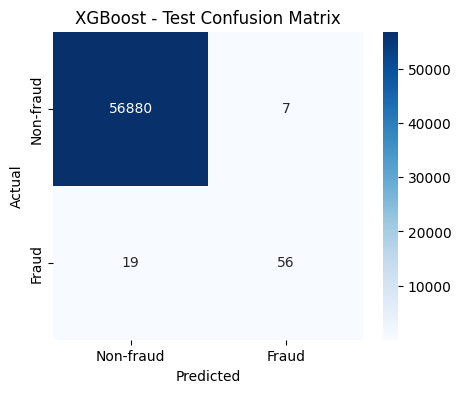

TN: 56880
FP: 7
FN: 19
TP: 56


In [24]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-fraud", "Fraud"],
    yticklabels=["Non-fraud", "Fraud"]
)
plt.title(f"{best_model_name} - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

## 20. Feature Importance

Feature importance is calculated from the selected final model. This confirms that the interpretation step uses the same model that will be carried into Week 5, rather than an earlier or rejected candidate.

In [25]:
importance_df = pd.DataFrame({
    "feature": X_train_full.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df.head(20)

,feature,importance
14,V14,0.388871
4,V4,0.063093
46,log_amount_hour_interaction,0.036370
20,V20,0.033249
8,V8,0.029615
12,V12,0.027766
10,V10,0.023687
39,amount_ratio_5,0.019687
17,V17,0.018554
40,amount_ratio_10,0.018154


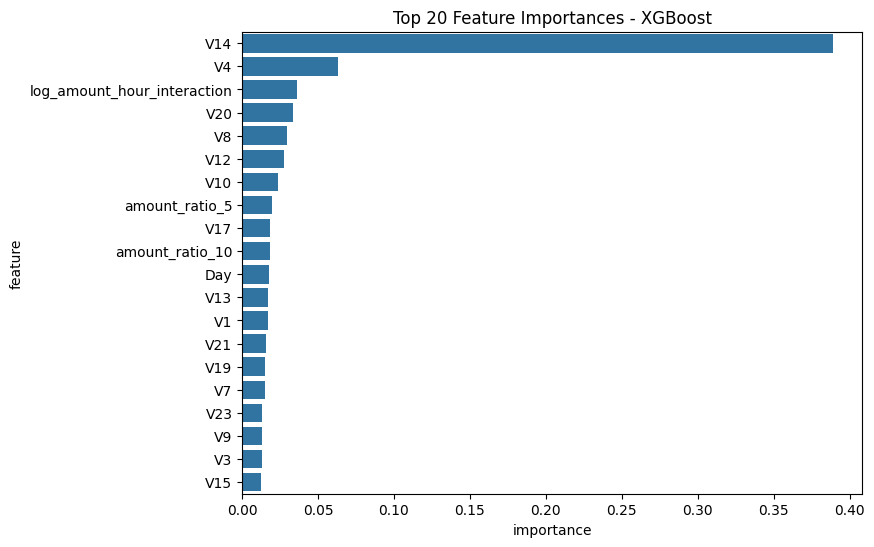

In [26]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)
plt.title(f"Top 20 Feature Importances - {best_model_name}")
plt.show()

## 21. Error Analysis for Explainability

The test predictions are separated into false negatives, false positives, and true positives. These groups are needed for Week 5 because SHAP/LIME should explain representative cases where fraud was caught, fraud was missed, and normal activity was incorrectly flagged.

In [27]:
test_analysis_df = X_test.copy()
test_analysis_df["actual"] = y_test.values
test_analysis_df["predicted"] = y_test_pred
test_analysis_df["fraud_probability"] = y_test_prob

false_negatives = test_analysis_df[
    (test_analysis_df["actual"] == 1) &
    (test_analysis_df["predicted"] == 0)
]

false_positives = test_analysis_df[
    (test_analysis_df["actual"] == 0) &
    (test_analysis_df["predicted"] == 1)
]

true_positives = test_analysis_df[
    (test_analysis_df["actual"] == 1) &
    (test_analysis_df["predicted"] == 1)
]

print("False negatives:", false_negatives.shape)
print("False positives:", false_positives.shape)
print("True positives:", true_positives.shape)

False negatives: (19, 50)
False positives: (7, 50)
True positives: (56, 50)


In [28]:
false_negatives.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,amount_ratio_10,amount_roll_median_10,amount_dev_median_10,tx_count_proxy_5,tx_count_proxy_10,amount_time_interaction,log_amount_hour_interaction,actual,predicted,fraud_probability
1885,146026.0,1.894036,1.905806,-3.515730,4.508913,2.044466,-1.420468,1.057480,-0.281157,-1.832604,...,0.007845,31.575,-29.355,5.0,10.0,2.220,18.710102,1,0,0.027600
4135,146998.0,-2.064240,2.629739,-0.748406,0.694992,0.418178,1.392520,-1.697801,-6.333065,1.724184,...,0.332626,13.975,-5.975,5.0,10.0,8.000,35.155593,1,0,0.002321
5410,147501.0,-1.611877,-0.408410,-3.829762,6.249462,-3.360922,1.147964,1.858425,0.474858,-3.838399,...,5.971481,19.990,976.280,5.0,10.0,498.135,110.480345,1,0,0.576108
10621,149676.0,1.833191,0.745333,-1.133009,3.893556,0.858164,0.910235,-0.498200,0.344703,-0.667939,...,0.515748,20.195,-2.805,5.0,10.0,17.390,49.500720,1,0,0.011813
11656,150139.0,-6.682832,-2.714268,-5.774530,1.449792,-0.661836,-1.148650,0.849686,0.433427,-1.315646,...,5.386274,8.970,228.290,5.0,10.0,237.260,93.047163,1,0,0.029425


In [29]:
false_positives.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,amount_ratio_10,amount_roll_median_10,amount_dev_median_10,tx_count_proxy_5,tx_count_proxy_10,amount_time_interaction,log_amount_hour_interaction,actual,predicted,fraud_probability
659,145538.0,-1.068669,4.016917,-3.366334,3.586212,3.395280,-1.562150,1.758914,-0.744804,-3.048548,...,0.006496,19.350,-18.580,5.0,10.0,0.770,9.135673,0,1,0.988036
9346,149133.0,-4.427152,-0.963508,-3.988525,5.993927,-3.236609,2.615496,3.109868,-0.375602,-2.814237,...,6.527081,20.500,1038.780,5.0,10.0,1059.280,118.426901,0,1,0.766567
35126,160739.0,1.014360,-0.443397,-1.656256,4.513472,0.171940,-0.301232,0.707661,-0.177134,-0.878233,...,5.836811,35.015,416.795,5.0,10.0,225.905,122.309452,0,1,0.902811
38745,162400.0,-1.244828,3.268775,-3.099748,3.567504,3.485373,-2.336792,1.827911,0.097761,-2.929137,...,0.007486,34.575,-33.805,5.0,10.0,0.385,11.990570,0,1,0.970137
39915,162916.0,-0.400517,3.514639,-2.902389,3.550913,3.568916,-1.575009,2.282890,-0.257712,-3.110190,...,0.022026,17.145,-16.375,5.0,10.0,0.385,11.990570,0,1,0.911396


In [30]:
true_positives.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,amount_ratio_10,amount_roll_median_10,amount_dev_median_10,tx_count_proxy_5,tx_count_proxy_10,amount_time_interaction,log_amount_hour_interaction,actual,predicted,fraud_probability
1866,146022.0,0.908637,2.849024,-5.647343,6.009415,0.216656,-2.397014,-1.819308,0.338527,-2.819883,...,0.035776,28.555,-27.375,5.0,10.0,1.18,12.469198,1,1,0.999982
2231,146179.0,-0.067672,4.251181,-6.540388,7.283657,0.513541,-2.635066,-1.865911,0.780272,-3.868248,...,0.008569,31.400,-30.630,5.0,10.0,0.77,9.135673,1,1,0.999899
2631,146344.0,-0.099724,2.795414,-6.423856,3.247513,-1.632290,-2.766665,-2.312223,0.961014,-1.896001,...,1.052912,48.185,46.635,5.0,10.0,94.82,72.999543,1,1,0.999792
6729,148028.0,-1.053840,4.362801,-6.023534,5.304534,1.480738,-2.193821,-1.530817,0.626857,-4.037021,...,0.000000,24.970,-24.970,5.0,10.0,0.00,0.000000,1,1,0.999926
6787,148053.0,1.261324,2.726800,-5.435019,5.342759,1.447043,-1.442584,-0.898702,0.123062,-2.748496,...,0.030643,7.180,-5.590,5.0,10.0,1.59,16.178184,1,1,0.995224


## 22. Save Reports, Case Files, and Model Artifacts

This cell saves validation results, threshold-tuning tables, final test metrics, feature importance, error-analysis case files, and the final model artifacts. The `_cases.csv` files are named for direct reuse in the explainability notebook.

In [31]:
reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)

results_df.to_csv(reports_dir / "model_validation_results.csv", index=False)
rf_threshold_df.to_csv(reports_dir / "rf_threshold_tuning_results.csv", index=False)
xgb_threshold_df.to_csv(reports_dir / "xgb_threshold_tuning_results.csv", index=False)
final_metrics_df.to_csv(reports_dir / "final_test_metrics.csv", index=False)
importance_df.to_csv(reports_dir / "final_feature_importance.csv", index=False)

if best_model_name == "XGBoost":
    importance_df.to_csv(reports_dir / "xgb_feature_importance.csv", index=False)

false_negatives.to_csv(reports_dir / "false_negatives.csv", index=False)
false_positives.to_csv(reports_dir / "false_positives.csv", index=False)
true_positives.to_csv(reports_dir / "true_positives.csv", index=False)

# Case files are named for direct reuse in Week 5 SHAP/LIME.
true_positives.to_csv(reports_dir / "true_positives_cases.csv", index=False)
false_negatives.to_csv(reports_dir / "false_negatives_cases.csv", index=False)
false_positives.to_csv(reports_dir / "false_positives_cases.csv", index=False)

model_metadata = {
    "model_name": best_model_name,
    "threshold": best_threshold,
    "validation_selection": best_validation_row.to_dict(),
    "test_metrics": final_metrics,
    "feature_count": len(X_train_full.columns)
}

saved_artifacts = {
    "model": joblib.dump(final_model, "../models/final_fraud_model.pkl"),
    "feature_list": joblib.dump(X_train_full.columns.tolist(), "../models/feature_list.pkl"),
    "threshold": joblib.dump(best_threshold, "../models/best_threshold.pkl"),
    "metadata": joblib.dump(model_metadata, "../models/final_model_metadata.pkl")
}

saved_reports = sorted(path.name for path in reports_dir.glob("*.csv"))

{
    "artifacts": saved_artifacts,
    "reports": saved_reports
}

{'artifacts': {'model': ['../models/final_fraud_model.pkl'],
  'feature_list': ['../models/feature_list.pkl'],
  'threshold': ['../models/best_threshold.pkl'],
  'metadata': ['../models/final_model_metadata.pkl']},
 'reports': ['false_negatives.csv',
  'false_negatives_cases.csv',
  'false_positives.csv',
  'false_positives_cases.csv',
  'final_evidence_inventory.csv',
  'final_feature_importance.csv',
  'final_test_metrics.csv',
  'model_validation_results.csv',
  'rf_threshold_tuning_results.csv',
  'true_positives.csv',
  'true_positives_cases.csv',
  'week6_batch_latency_summary.csv',
  'week6_batch_prediction_sample.csv',
  'week6_batch_prediction_test.csv',
  'week6_latency_summary.csv',
  'week6_latency_test.csv',
  'week6_manual_pipeline_comparison.csv',
  'week6_single_prediction_test.csv',
  'week6_src_file_status.csv',
  'week6_stream_simulation.csv',
  'week6_stream_simulation_mixed.csv',
  'week6_submission_file_inventory.csv',
  'week7_api_latency_summary.csv',
  'week7_a

## Summary of Week 4 Modeling and Evaluation

In this stage, five baseline models were evaluated for credit card fraud detection, including Dummy Classifier, Logistic Regression, Random Forest, XGBoost, and LightGBM. Because the dataset is extremely imbalanced, model evaluation focused on PR-AUC, ROC-AUC, Precision, Recall, and F1-score rather than accuracy alone.

The validation results showed that Random Forest and XGBoost were the two strongest candidates. LightGBM performed poorly under the current configuration and was therefore not selected as the final model. After threshold tuning on the validation set, XGBoost with a decision threshold of 0.73 was selected as the final model configuration due to its strong balance between precision and recall.

On the held-out test set, the final XGBoost model achieved a ROC-AUC of 0.9815 and a PR-AUC of 0.7892. For the fraud class, the model achieved a precision of 0.8889, recall of 0.7467, and F1-score of 0.8116. The confusion matrix showed that the model correctly detected 56 fraudulent transactions, missed 19 fraudulent transactions, and incorrectly flagged only 7 normal transactions.

These results indicate that the model provides a strong trade-off between fraud detection capability and false alert control. Error-analysis cases were separated into true positives, false negatives, and false positives so they can be reused in Week 5 for SHAP/LIME explanations.

The trained XGBoost model, selected threshold, feature list, validation results, threshold tuning results, final test metrics, ROC/PR plots, feature importance, and error-analysis case files were saved for the next stage.

### Reporting Notes

Accuracy is reported for completeness, but it is not the primary evaluation metric due to the severe class imbalance. Precision, recall, F1-score, and PR-AUC should be emphasized in the report.

If preprocessing objects such as scalers are used in the deployment pipeline, they should be fit on training data only and then applied to validation/test data. This avoids data leakage in future production-style experiments.

The current notebook is an offline model evaluation stage. The trained model and selected threshold should be described as the core inference component for a simulated real-time fraud detection pipeline, not as a fully deployed real-time system yet.